#### Download Checkpoints
If the checkpoints cannot be downloaded successfully using the provided code, please download them manually from the following link.

In [1]:
import os
import gdown

url = "https://drive.google.com/drive/folders/14_82FwfaOxERGILfYU3zDlQrvpZR7NEc?usp=drive_link"
output_dir = "checkpoints"

if os.path.exists(output_dir) and len(os.listdir(output_dir)) > 0:
    print(f"{output_dir} already exists and is not empty, skip downloading.")
else:
    gdown.download_folder(
        url=url,
        output=output_dir,
        quiet=False,
        use_cookies=False
    )

checkpoints already exists and is not empty, skip downloading.


#### Process data from NMRPipe

float32


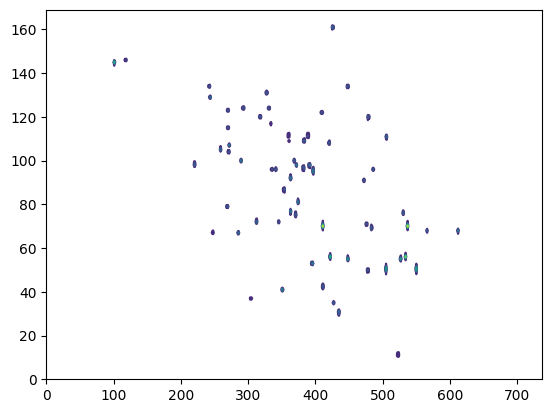

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import nmrglue as ng
import scipy.io as sio
file_path = r'./data/Processed_Data/GB1_input1.ft2'
dic, input_data = ng.pipe.read(file_path)
print(input_data.dtype)
#Combine data
input_data=input_data[0::2,:]+1j*input_data[1::2,:]
#Conduct fourier transform (In NMRPipe, a Fourier transform has already been performed along the direct dimension)
input_data=np.fft.fft(input_data,axis=0)
plt.contour(np.abs((input_data)))
sio.savemat("./data/Processed_Data/GB1.mat",{"LR":input_data})

#### Reconstruct 2D data

export CUDA_VISIBLE_DEVICES=0
setting opt['gpu_ids'] = [0]
block_num =  3
torch.Size([3, 256, 256])


sampling loop time step: 100%|██████████| 2000/2000 [00:41<00:00, 48.74it/s]  


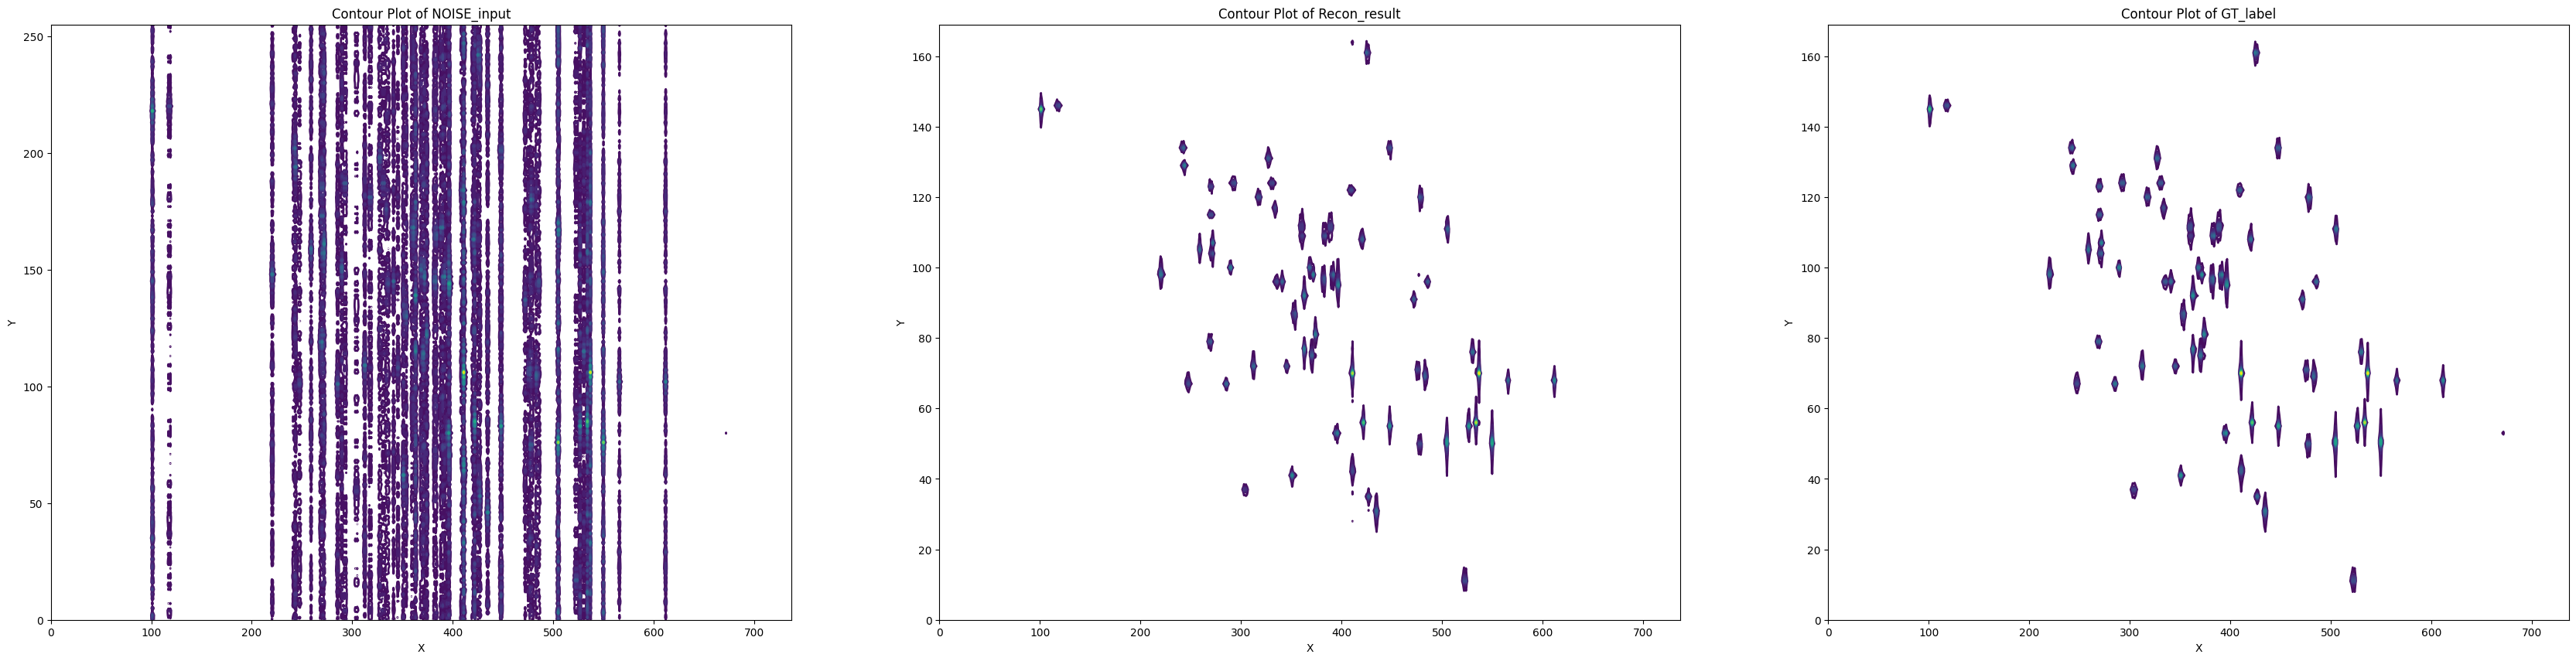

In [ ]:
import os
import torch
import numpy as np
import torch
import model.model256 as Model
import argparse
import core.logger as Logger
import core.metrics as Metrics
import os
import torch
import random
import scipy.io as scio
import matplotlib.pyplot as plt

# os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:128'
parser = argparse.ArgumentParser()
parser.add_argument('-c', '--config', type=str, default='config/sr_sr3_256_256_val256.json',
                        help='JSON file for configuration')
parser.add_argument('-p', '--phase', type=str, choices=['train', 'val'],
                        help='Run either train(training) or val(generation)', default='val')
parser.add_argument('-gpu', '--gpu_ids', type=str, default=None)
parser.add_argument('-debug', '-d', action='store_true')
parser.add_argument('-enable_wandb', action='store_true')
parser.add_argument('-log_wandb_ckpt', action='store_true')
parser.add_argument('-log_eval', action='store_true')

args = parser.parse_args(args=[])
opt = Logger.parse(args)
opt = Logger.dict_to_nonedict(opt)

# logging
torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark = True

def pad_data(data, block_size):
    
    height, width = data.shape

    
    pad_height = (block_size - height % block_size) % block_size
    pad_width = (block_size - width % block_size) % block_size

    padded_data = np.pad(data, ((0, pad_height), (0, pad_width)), mode='constant', constant_values=0)

    return padded_data, pad_height, pad_width


def block_data(data, block_size):
    
    padded_data, pad_height, pad_width = pad_data(data, block_size)

    
    height, width = padded_data.shape

    
    num_blocks_vertical = height // block_size
    num_blocks_horizontal = width // block_size

    
    blocks = np.empty((num_blocks_vertical * num_blocks_horizontal, block_size, block_size), dtype=padded_data.dtype)

    
    idx = 0
    for i in range(num_blocks_vertical):
        for j in range(num_blocks_horizontal):
            block = padded_data[i * block_size:(i + 1) * block_size, j * block_size:(j + 1) * block_size]
            blocks[idx] = block
            idx += 1

    return blocks, padded_data.shape, pad_height, pad_width


def reconstruct_data(blocks, pad_shape, pad_height, pad_width):
    
    height, width = pad_shape

    
    num_blocks, block_height, block_width = blocks.shape

    
    num_blocks_vertical = height // block_height
    num_blocks_horizontal = width // block_width

    
    reconstructed_data = np.empty((height, width), dtype=blocks.dtype)

    
    idx = 0
    for i in range(num_blocks_vertical):
        for j in range(num_blocks_horizontal):
            block = blocks[idx]
            reconstructed_data[i * block_height:(i + 1) * block_height, j * block_width:(j + 1) * block_width] = block
            idx += 1

    
    final_data = reconstructed_data[:height if not pad_height else -pad_height, :width if not pad_width else -pad_width]

    return final_data


data_path = f"{opt['datasets']['test']['real_data_path']}.mat"
sample_rate = opt['datasets']['test']['sample_rate']
ori_spec = scio.loadmat(data_path)['LR']
N1 = ori_spec.shape[0]
N2 = ori_spec.shape[1]

xx = np.fft.ifft(ori_spec, axis=0)
Mask = scio.loadmat(f"./data/data256/{sample_rate}_stack_mask-{N1}-{N2}/Mask.mat")['Mask']
xx = np.pad(xx, ((0,256-N1),(0,0)))
Mask = np.pad(Mask, ((0,256-N1),(0,0)))
phase_input, pad_shape, pad_height, pad_width = block_data(xx, 256)

NUS_FID = np.multiply(Mask, xx)
# NUS_FID = xx
NOISE_input = np.fft.fft(NUS_FID, axis=0)
NUS_FID, _, _, _ = block_data(NUS_FID, 256)
NOISE_input, _, _, _ = block_data(NOISE_input, 256)

GT_label = np.fft.fft(xx, axis=0)
GT_label, _, _, _ = block_data(GT_label, 256)
block_num = phase_input.shape[0]
print("block_num = ", block_num)

max_amp = np.max(np.abs(NOISE_input))
NUS_FID = torch.complex(torch.from_numpy(NUS_FID.real).float(), torch.from_numpy(NUS_FID.imag).float()) / (
            max_amp * (1/sample_rate))
NOISE_input = torch.complex(torch.from_numpy(NOISE_input.real).float(), torch.from_numpy(NOISE_input.imag).float()) / (
    max_amp)
GT_label = torch.complex(torch.from_numpy(GT_label.real).float(), torch.from_numpy(GT_label.imag).float()) / (
            max_amp * (1/sample_rate))

LR = NUS_FID.unsqueeze(1)
SR = torch.cat((NOISE_input.real.unsqueeze(1), NOISE_input.imag.unsqueeze(1)), dim=1)
HR = torch.cat((GT_label.real.unsqueeze(1), GT_label.imag.unsqueeze(1)), dim=1)
print(GT_label.shape)
val_data = {'LR': LR, 'HR': HR, 'SR': SR}

diffusion = Model.create_model(opt)
avg_mse = 0.0
result_path = '{}/{}'.format(opt['path']['results'], 100)
os.makedirs(result_path, exist_ok=True)
diffusion.set_new_noise_schedule(opt['model']['beta_schedule']['val'], schedule_phase='val')

val_data = diffusion.set_device(val_data)
diffusion.feed_data(val_data)
diffusion.test(continous=False)
visuals = diffusion.get_current_visuals()

try:
    if block_num is not None:
        fake_img = reconstruct_data(torch.complex(visuals['INF'][0 : block_num , 0], visuals['INF'][0 : block_num , 1]).cpu().numpy(), pad_shape, pad_height, pad_width)
        sr_img = reconstruct_data(torch.complex(visuals['SR'][-block_num : , 0], visuals['SR'][-block_num : , 1]).cpu().numpy(), pad_shape, pad_height, pad_width)
        sr_spec = reconstruct_data(torch.complex(visuals['SR_Spec'][-block_num : , 0], visuals['SR_Spec'][-block_num :, 1]).cpu().numpy(), pad_shape, pad_height, pad_width)
        hr_img = reconstruct_data(torch.complex(visuals['HR'][0 : block_num , 0], visuals['HR'][0 : block_num , 1]).cpu().numpy(), pad_shape, pad_height, pad_width)
        lr_img = reconstruct_data(visuals['LR'][0 : block_num].squeeze(1).cpu().numpy(), pad_shape, pad_height, pad_width)

except NameError:
    fake_img = torch.complex(visuals['INF'][0, 0], visuals['INF'][0, 1]).squeeze().cpu().numpy()
    sr_img = torch.complex(visuals['SR'][-1, 0], visuals['SR'][-1, 1]).squeeze().cpu().numpy()
    sr_spec = torch.complex(visuals['SR_Spec'][-1, 0], visuals['SR_Spec'][-1, 1]).squeeze().cpu().numpy()
    hr_img = torch.complex(visuals['HR'][0, 0], visuals['HR'][0, 1]).squeeze().cpu().numpy()
    lr_img = visuals['LR'][0].squeeze().float().cpu().numpy()

sr_img = np.fft.fft(np.fft.ifft(sr_img, axis=0)[:N1, :], axis=0)
hr_img = np.fft.fft(xx[:N1, :], axis=0)
Metrics.save_contour2(
nus_spec=fake_img,
recon_spec=sr_img,
label_spec=hr_img,
sr_spec=sr_spec,  # result of densenet
save_path='{}/{}_{}_hr.png'.format(result_path, 200, 1))
plt.show()

scio.savemat('./data/label_spec_2D.mat', {'label_spec': hr_img})
scio.savemat('./data/recon_spec_2D.mat', {'recon_spec': sr_img})

#### Save the reconstructed data into NMRPipe format

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import nmrglue as ng
import scipy.io as sio
file_path = r'./data/Processed_Data/GB1_input.ft2'
dic, input_data = ng.pipe.read(file_path)
#Load reconstructed data
recon_spec=sio.loadmat("./data/recon_spec_2D.mat")["recon_spec"]
#Conduct inverse fourier transform
recon_spec=np.fft.ifft(recon_spec,axis=0)

a,b=recon_spec.shape
ouptut_data=np.zeros([2*a,b],dtype=np.float32)
ouptut_data[0::2,:]=recon_spec.real
ouptut_data[1::2,:]=recon_spec.imag
print(ouptut_data.shape)
#Rewrite Data
ng.pipe.write("./data/Processed_Data/GB1_recon.ft2", dic, ouptut_data, overwrite=True)

FileNotFoundError: [Errno 2] No such file or directory: './data/Processed_Data/GB1_input.ft2'